In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score,
    balanced_accuracy_score, f1_score, confusion_matrix)
from xgboost import XGBClassifier
import shap

 import numpy as np
import pandas as pd
from scipy import stats
import re
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CYCLES = ["E", "F", "G"]
FILES = ["DEMO", "BMX", "CBC", "ENX", "MCQ", "OCQ", "RDQ", "SMQ", "SPX"]
WT_COL, PSU_COL, STRATA_COL = "WTMEC2YR", "SDMVPSU", "SDMVSTRA"
N_CYCLES = len(CYCLES)

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
SEARCH_ROOT = KAGGLE_INPUT_ROOT if KAGGLE_INPUT_ROOT.exists() else Path("/mnt/data")
print("Search root:", SEARCH_ROOT)

In [ ]:
def discover_nhanes_files(search_root=SEARCH_ROOT):
    file_map = {}
    pattern = re.compile(r"(DEMO|BMX|CBC|ENX|MCQ|OCQ|RDQ|SMQ|SPX)_([EFG])")
    for path in search_root.rglob("*"):
        if not path.is_file() or path.suffix.lower() != ".xpt":
            continue
        stem = re.sub(r"\(\d+\)$", "", path.stem.upper().replace(" ", ""))
        m = pattern.fullmatch(stem)
        if not m:
            continue
        key = m.groups()
        if key not in file_map or "(" not in path.stem:
            file_map[key] = path
    return file_map

XPT_FILE_MAP = discover_nhanes_files()
expected = {(mod, cyc) for cyc in CYCLES for mod in FILES}
missing = sorted(expected - set(XPT_FILE_MAP))
print(f"Detected {len(XPT_FILE_MAP)} of {len(expected)} required XPT files.")
if missing:
    raise FileNotFoundError("Missing: " + ", ".join(f"{m}_{c}" for m, c in missing))

In [ ]:
def load_xpt(module, cycle):
    path = XPT_FILE_MAP[(module, cycle)]
    df = pd.read_sas(path, format="xport", encoding="latin-1")
    df.columns = [str(c).strip().upper() for c in df.columns]
    if "SEQN" not in df.columns:
        raise KeyError(f"SEQN missing from {path.name}")
    if df["SEQN"].duplicated().any():
        raise ValueError(f"{path.name} has duplicate SEQN")
    return df

def load_cycle(cycle):
    merged = load_xpt("DEMO", cycle).copy()
    for module in FILES[1:]:
        right = load_xpt(module, cycle).copy()
        overlap = [c for c in right.columns if c != "SEQN" and c in merged.columns]
        if overlap:
            right = right.rename(columns={c: f"{c}_{module}" for c in overlap})
        merged = merged.merge(right, on="SEQN", how="left", validate="one_to_one")
    merged["CYCLE"] = cycle
    return merged

def build_merged(cycles=CYCLES):
    return pd.concat([load_cycle(c) for c in cycles],
                     axis=0, ignore_index=True, sort=False)

full = build_merged()
print("Merged shape:", full.shape)
for c in (WT_COL, PSU_COL, STRATA_COL):
    print(f"  {c}: present={c in full.columns}, missing={full[c].isna().sum()}")

In [ ]:
def build_cohort(full):
    age_ok = full["RIDAGEYR"].between(40, 79)
    asthma_flag = (full["MCQ010"] == 1) & (full["MCQ035"] == 1)

    fev1 = full["SPXBFEV1"].where(full["SPXBFEV1"].notna(), full["SPXNFEV1"])
    fvc  = full["SPXBFVC"].where(full["SPXBFVC"].notna(), full["SPXNFVC"])
    ratio = fev1 / fvc

    copd_self = (full["MCQ160G"] == 1) | (full["MCQ160K"] == 1)
    copd_flag = copd_self & (ratio < 0.70)

    overlap = asthma_flag & copd_flag
    keep = age_ok & (asthma_flag | copd_flag) & (~overlap)

    cohort = full.loc[keep].copy()
    cohort["target"] = asthma_flag.loc[cohort.index].astype(int).to_numpy()
    cohort["outcome_fev1"] = fev1.loc[cohort.index].to_numpy()
    cohort["outcome_fvc"] = fvc.loc[cohort.index].to_numpy()
    cohort["outcome_fev1_fvc_ratio"] = ratio.loc[cohort.index].to_numpy()
    cohort.attrs["n_overlap_excluded"] = int((age_ok & overlap).sum())
    return cohort

cohort = build_cohort(full)
print("Cohort:", cohort.shape, "| target counts:", cohort["target"].value_counts().to_dict())
print("ACO excluded:", cohort.attrs["n_overlap_excluded"])

In [ ]:
FEATURE_MAP = {
    "RIAGENDR": "gender", "RIDAGEYR": "age", "RIDRETH1": "race_ethnicity",
    "DMDEDUC2": "education", "INDFMPIR": "poverty_income_ratio",
    "SMQ020": "ever_smoked_100", "SMQ040": "current_smoking_status",
    "OCD150": "work_status",
    "RDQ031": "wheeze_past_12mo", "RDQ070": "cough_most_days",
    "RDQ080": "phlegm_most_days", "RDQ090": "cough_phlegm_3mo",
    "RDQ100": "wheeze_exercise", "RDQ140": "wheeze_disturbs_sleep",
    "BMXBMI": "bmi", "BMXWAIST": "waist_circumference",
    "LBXWBCSI": "wbc_count", "LBXEOPCT": "eosinophil_pct",
    "LBDEONO": "eosinophil_count", "ENXMEAN": "feno_mean",
    "SPXNFEV1": "fev1", "SPXNFVC": "fvc", "SPXNPEF": "pef",
}
NUMERIC_COLS = ["age", "poverty_income_ratio", "bmi", "waist_circumference",
                "wbc_count", "eosinophil_pct", "eosinophil_count", "feno_mean",
                "fev1", "fvc", "pef", "fev1_fvc_ratio"]
SPX_FEATURES = ["fev1", "fvc", "pef", "fev1_fvc_ratio"]
LAB_FEATURES = ["wbc_count", "eosinophil_pct", "eosinophil_count", "feno_mean"]

def build_features(cohort):
    X = cohort[list(FEATURE_MAP.keys())].rename(columns=FEATURE_MAP).copy()
    X["fev1_fvc_ratio"] = X["fev1"] / X["fvc"]
    y = cohort["target"].copy()
    for c in ["phlegm_most_days", "wheeze_exercise", "cough_phlegm_3mo"]:
        X[c] = X[c].fillna(0).replace({2: 0})
    for c in ["ever_smoked_100", "wheeze_past_12mo", "cough_most_days",
              "wheeze_disturbs_sleep", "gender", "current_smoking_status", "work_status"]:
        X[c] = X[c].replace({7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan})
    categorical_cols = [c for c in X.columns if c not in NUMERIC_COLS]
    return X, y, categorical_cols

X, y, categorical_cols = build_features(cohort)
print("Feature matrix:", X.shape, "| categorical:", len(categorical_cols))

In [ ]:
def build_preprocessor(categorical_cols, numeric_cols):
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ])

def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    return list(numeric_cols) + list(ohe.get_feature_names_out(categorical_cols))

def get_model_specs(scale_pos_weight):
    return {
        "Logistic Regression": (
            LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__C": np.logspace(-3, 2, 20), "clf__penalty": ["l2"]}),
        "SVM": (
            SVC(probability=True, random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__C": np.logspace(-2, 2, 15), "clf__gamma": ["scale", "auto"],
             "clf__kernel": ["rbf"]}),
        "Random Forest": (
            RandomForestClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__n_estimators": [200, 400, 600], "clf__max_depth": [None, 5, 8, 12],
             "clf__min_samples_leaf": [1, 2, 4, 8]}),
        "Extra Trees": (
            ExtraTreesClassifier(random_state=RANDOM_SEED, class_weight="balanced"),
            {"clf__n_estimators": [200, 400, 600], "clf__max_depth": [None, 5, 8, 12],
             "clf__min_samples_leaf": [1, 2, 4, 8]}),
        "XGBoost (regularized)": (
            XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss",
                          scale_pos_weight=scale_pos_weight, verbosity=0, n_jobs=1),
            {"clf__n_estimators": [200, 400], "clf__max_depth": [2, 3, 4, 5],
             "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
             "clf__reg_alpha": [0, 0.1, 0.5, 1.0], "clf__reg_lambda": [1.0, 2.0, 5.0, 10.0],
             "clf__subsample": [0.6, 0.8, 1.0], "clf__colsample_bytree": [0.6, 0.8, 1.0]}),
    }

def best_threshold(y_true, proba):
    ts = np.linspace(0.05, 0.95, 181)
    scores = [balanced_accuracy_score(y_true, (proba >= t).astype(int)) for t in ts]
    i = int(np.argmax(scores))
    return float(ts[i]), float(scores[i])

def evaluate(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"AUROC": roc_auc_score(y_true, proba),
            "Accuracy": accuracy_score(y_true, pred),
            "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
            "Macro_F1": f1_score(y_true, pred, average="macro"),
            "Asthma_Sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
            "COPD_Sensitivity": tn / (tn + fp) if (tn + fp) else np.nan}

def make_arm(X, drop_cols):
    Xa = X.drop(columns=[c for c in drop_cols if c in X.columns])
    num_c = [c for c in NUMERIC_COLS if c in Xa.columns]
    cat_c = [c for c in Xa.columns if c not in num_c]
    return Xa, num_c, cat_c

In [ ]:
def run_single_split(X, y, numeric_cols, categorical_cols, n_iter=30):
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_temp)
    print(f"train={len(y_train)} val={len(y_val)} test={len(y_test)} "
          f"| test COPD n={(y_test == 0).sum()}")

    spw = (y_train == 0).sum() / (y_train == 1).sum()
    prep = build_preprocessor(categorical_cols, numeric_cols)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    fitted, test_probs, results = {}, {}, []
    for name, (clf, params) in get_model_specs(spw).items():
        search = RandomizedSearchCV(Pipeline([("prep", prep), ("clf", clf)]),
            params, n_iter=n_iter, scoring="roc_auc", cv=cv,
            random_state=RANDOM_SEED, n_jobs=-1)
        search.fit(X_train, y_train)
        best = search.best_estimator_
        fitted[name] = best
        t_star, _ = best_threshold(y_val, best.predict_proba(X_val)[:, 1])
        proba_test = best.predict_proba(X_test)[:, 1]
        test_probs[name] = proba_test
        m = evaluate(y_test, proba_test, t_star)
        m.update({"Model": name, "CV_best_AUC": search.best_score_, "Threshold": t_star})
        results.append(m)
        print(f"{name}: innerCV={search.best_score_:.4f} thr={t_star:.3f} "
              f"test={m['AUROC']:.4f} balacc={m['Balanced_Accuracy']:.4f}")
    return pd.DataFrame(results).sort_values("AUROC", ascending=False), fitted, test_probs, y_test

In [ ]:
def run_nested_repeated_cv(X, y, numeric_cols, categorical_cols,
                           n_splits=5, n_repeats=10, n_iter=20,
                           inner_val_frac=0.25, verbose=True):
    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats,
                                  random_state=RANDOM_SEED)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    rows, n_folds = [], n_splits * n_repeats

    for fold_i, (tr, te) in enumerate(rkf.split(X, y), start=1):
        X_otr, y_otr = X.iloc[tr], y.iloc[tr]
        X_te, y_te = X.iloc[te], y.iloc[te]
        X_in, X_val, y_in, y_val = train_test_split(
            X_otr, y_otr, test_size=inner_val_frac,
            random_state=RANDOM_SEED, stratify=y_otr)
        spw = (y_in == 0).sum() / (y_in == 1).sum()
        prep = build_preprocessor(categorical_cols, numeric_cols)

        for name, (clf, params) in get_model_specs(spw).items():
            search = RandomizedSearchCV(Pipeline([("prep", prep), ("clf", clf)]),
                params, n_iter=n_iter, scoring="roc_auc", cv=inner_cv,
                random_state=RANDOM_SEED, n_jobs=-1)
            search.fit(X_in, y_in)
            best = search.best_estimator_
            t_star, _ = best_threshold(y_val, best.predict_proba(X_val)[:, 1])
            m = evaluate(y_te, best.predict_proba(X_te)[:, 1], t_star)
            m.update({"Model": name, "Fold": fold_i, "Threshold": t_star,
                      "Inner_CV_AUC": search.best_score_})
            rows.append(m)
        if verbose and fold_i % 5 == 0:
            print(f"    fold {fold_i}/{n_folds}", flush=True)
    return pd.DataFrame(rows)

def summarise_folds(fold_df):
    metrics = ["AUROC", "Balanced_Accuracy", "Macro_F1",
               "Asthma_Sensitivity", "COPD_Sensitivity", "Threshold"]
    out = []
    for model, g in fold_df.groupby("Model"):
        row = {"Model": model, "N_folds": len(g)}
        for m in metrics:
            row[f"{m}_mean"] = g[m].mean(); row[f"{m}_sd"] = g[m].std(ddof=1)
            row[f"{m}_lo"] = g[m].quantile(0.025); row[f"{m}_hi"] = g[m].quantile(0.975)
        out.append(row)
    return pd.DataFrame(out).sort_values("AUROC_mean", ascending=False)

In [ ]:
def bootstrap_ci(y_true, proba, threshold, n_boot=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    y_true, proba = np.asarray(y_true), np.asarray(proba)
    ipos, ineg = np.where(y_true == 1)[0], np.where(y_true == 0)[0]
    reps = []
    for _ in range(n_boot):
        bs = np.concatenate([rng.choice(ipos, len(ipos), replace=True),
                             rng.choice(ineg, len(ineg), replace=True)])
        try:
            reps.append(evaluate(y_true[bs], proba[bs], threshold))
        except ValueError:
            continue
    reps = pd.DataFrame(reps)
    return pd.DataFrame({"point": pd.Series(evaluate(y_true, proba, threshold)),
                         "ci_lo": reps.quantile(0.025), "ci_hi": reps.quantile(0.975)})

In [ ]:
Xa, num_a, cat_a = make_arm(X, [])
results_df, fitted, test_probs, y_test = run_single_split(X, y, num_a, cat_a)
print("\n=== Single split, full feature set ===")
print(results_df.to_string(index=False))

print("\n=== Bootstrap 95% CIs (test set) ===")
for name, proba in test_probs.items():
    thr = float(results_df.loc[results_df["Model"] == name, "Threshold"].iloc[0])
    print(f"\n--- {name} (thr={thr:.3f}) ---")
    print(bootstrap_ci(y_test, proba, thr).round(4).to_string())

In [ ]:
def run_shap_analysis(X, y, numeric_cols, categorical_cols,
                      model_name="Random Forest", n_iter=30, top_n=15):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    prep = build_preprocessor(categorical_cols, numeric_cols)
    clf, params = get_model_specs(spw)[model_name]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    search = RandomizedSearchCV(Pipeline([("prep", prep), ("clf", clf)]), params,
        n_iter=n_iter, scoring="roc_auc", cv=cv, random_state=RANDOM_SEED, n_jobs=-1)
    search.fit(X_tr, y_tr)
    pipe = search.best_estimator_

    prep_f, clf_f = pipe.named_steps["prep"], pipe.named_steps["clf"]
    names = get_feature_names(prep_f, numeric_cols, categorical_cols)
    X_te_enc = prep_f.transform(X_te)
    if hasattr(X_te_enc, "toarray"):
        X_te_enc = X_te_enc.toarray()

    sv = shap.TreeExplainer(clf_f).shap_values(X_te_enc)
    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]

    imp = (pd.DataFrame({"feature": names, "mean_abs_shap": np.abs(sv).mean(axis=0)})
           .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
    print(f"\n=== SHAP global importance ({model_name}, top {top_n}) ===")
    print(imp.head(top_n).to_string(index=False))
    shap.summary_plot(sv, X_te_enc, feature_names=names, show=False)
    plt.tight_layout(); plt.savefig(f"shap_{model_name.replace(' ', '_')}.png", dpi=150); plt.show()
    return imp, sv, names

X_nospx, num_nospx, cat_nospx = make_arm(X, SPX_FEATURES)
imp_nospx, sv_nospx, names_nospx = run_shap_analysis(
    X_nospx, y, num_nospx, cat_nospx, model_name="Random Forest")

In [ ]:
def add_pooled_weight(df):
    df = df.copy()
    df["w6yr"] = df[WT_COL] / N_CYCLES
    return df

def weighted_mean(df, col, wcol="w6yr"):
    m = df[col].notna() & df[wcol].notna()
    return np.average(df.loc[m, col], weights=df.loc[m, wcol])

def weighted_prop(df, mask, wcol="w6yr"):
    m = df[wcol].notna()
    return df.loc[m & mask, wcol].sum() / df.loc[m, wcol].sum()

cohort_w = add_pooled_weight(cohort)
print("Unweighted n:", len(cohort_w))
print("Sum of 6-year MEC weights:", f"{cohort_w['w6yr'].sum():,.0f}")
print("Strata:", cohort_w[STRATA_COL].nunique(),
      "| PSUs:", cohort_w.groupby(STRATA_COL)[PSU_COL].nunique().sum())
print("Zero-weight rows (not MEC-examined):", int((cohort_w[WT_COL] == 0).sum()))

In [ ]:
%%time
_X, _n, _c = make_arm(X, SPX_FEATURES)
_ = run_nested_repeated_cv(_X, y, _n, _c, n_repeats=1, n_iter=10)

In [ ]:
ARMS = {"A_full": [], "B_no_ratio": ["fev1_fvc_ratio"], "C_no_spx": SPX_FEATURES}

arm_summary = {}
for arm, drop in ARMS.items():
    print(f"\n=== Arm {arm} ===", flush=True)
    Xa, num_c, cat_c = make_arm(X, drop)
    print(f"  {Xa.shape[1]} features", flush=True)
    folds = run_nested_repeated_cv(Xa, y, num_c, cat_c,
                                   n_splits=5, n_repeats=10, n_iter=20)
    folds.to_csv(f"nested_cv_folds_{arm}.csv", index=False)
    arm_summary[arm] = summarise_folds(folds)
    print(arm_summary[arm].round(4).to_string(index=False))

ablation = pd.DataFrame({a: arm_summary[a].set_index("Model")["AUROC_mean"] for a in ARMS})
ablation["ratio_only_effect"] = ablation["A_full"] - ablation["B_no_ratio"]
ablation["total_spx_effect"]  = ablation["A_full"] - ablation["C_no_spx"]
ablation["reconstructed"]     = ablation["B_no_ratio"] - ablation["C_no_spx"]
print("\n=== Ablation: mean nested-CV AUROC by arm ===")
print(ablation.round(4).to_string())
ablation.to_csv("ablation_three_arm.csv")

In [ ]:


def taylor_estimate(df, yvar, wvar="w6yr", stratum="SDMVSTRA", psu="SDMVPSU",
                    domain=None, alpha=0.05):
    """Weighted mean/proportion with a design-based standard error."""
    d = df.copy()
    if domain:
        inside = d[domain].fillna(False).astype(bool)
    else:
        inside = pd.Series(True, index=d.index)

    valid = inside & d[yvar].notna() & d[wvar].notna() & (d[wvar] > 0)

    w = np.where(valid, d[wvar].to_numpy(dtype=float), 0.0)
    yv = np.where(valid,
                  pd.to_numeric(d[yvar], errors="coerce").fillna(0).to_numpy(float),
                  0.0)

    sw = w.sum()
    if sw <= 0:
        raise ValueError(f"{yvar}: no positive weight in domain")
    theta = float((w * yv).sum() / sw)

    z = w * (yv - theta) / sw   # zero outside the domain, by construction

    work = pd.DataFrame({"z": z, "h": d[stratum].to_numpy(), "a": d[psu].to_numpy()})
    psu_tot = work.groupby(["h", "a"], sort=False)["z"].sum().reset_index()

    var = 0.0
    for _, g in psu_tot.groupby("h", sort=False):
        n_h = len(g)
        if n_h < 2:
            continue
        dev = g["z"].to_numpy() - g["z"].mean()
        var += n_h / (n_h - 1) * float((dev ** 2).sum())

    se = float(np.sqrt(max(var, 0.0)))
    dof = max(len(psu_tot) - psu_tot["h"].nunique(), 1)
    tcrit = stats.t.ppf(1 - alpha / 2, dof)

    return {"variable": yvar, "estimate": theta, "stderr": se,
            "lower_ci": theta - tcrit * se, "upper_ci": theta + tcrit * se,
            "df": dof, "n_unweighted": int(valid.sum()), "sum_weights": sw}


def taylor_by_domain(df, yvar, domain_col, levels, **kw):
    """Run taylor_estimate once per level of a categorical domain column."""
    out = []
    for lvl in levels:
        d = df.copy()
        d["_dom"] = (d[domain_col] == lvl)
        r = taylor_estimate(d, yvar, domain="_dom", **kw)
        r["domain"] = lvl
        out.append(r)
    return pd.DataFrame(out)

print("Functions loaded.")

Functions loaded.


In [44]:
# --- A. Population prevalence, adults 40-79 ---
print("=== Weighted prevalence, US adults aged 40-79 ===")
prev_rows = []
for flag, label in [("asthma_only", "Asthma only"),
                    ("copd_only", "COPD only"),
                    ("overlap", "Asthma-COPD overlap"),
                    ("no_disease", "Neither")]:
    r = taylor_estimate(svy, flag, domain="age_eligible")
    r["label"] = label
    prev_rows.append(r)
    print(f"  {label:22s} {r['estimate']*100:6.2f}%  "
          f"(SE {r['stderr']*100:.2f}, 95% CI "
          f"{r['lower_ci']*100:.2f}-{r['upper_ci']*100:.2f}, df={r['df']})")

prev = pd.DataFrame(prev_rows)
print(f"\n  Sum of four categories: {prev['estimate'].sum()*100:.2f}% (should be 100.00)")
asth = prev.loc[prev['label'] == 'Asthma only', 'estimate'].iloc[0]
copd = prev.loc[prev['label'] == 'COPD only', 'estimate'].iloc[0]
print(f"  Weighted asthma:COPD ratio {asth/copd:.2f} (unweighted 794/128 = 6.20)")
prev.to_csv("weighted_prevalence.csv", index=False)

# --- B. Table 1 by disease group ---
CONTINUOUS = {
    "RIDAGEYR": "Age, years", "BMXBMI": "BMI, kg/m2",
    "BMXWAIST": "Waist circumference, cm", "INDFMPIR": "Poverty-income ratio",
    "LBXWBCSI": "WBC count, 1000 cells/uL", "LBXEOPCT": "Eosinophils, %",
    "LBDEONO": "Eosinophil count, 1000 cells/uL", "ENXMEAN": "FeNO, ppb",
    "SPXNFEV1": "FEV1, mL", "SPXNFVC": "FVC, mL",
}
svy["female"] = (svy["RIAGENDR"] == 2).astype(float)
svy["ever_smoker"] = (svy["SMQ020"] == 1).astype(float)
svy["current_smoker"] = svy["SMQ040"].isin([1, 2]).astype(float)
svy["nh_white"] = (svy["RIDRETH1"] == 3).astype(float)
svy["nh_black"] = (svy["RIDRETH1"] == 4).astype(float)
BINARY = {"female": "Female", "ever_smoker": "Ever smoked 100+ cigarettes",
          "current_smoker": "Current smoker",
          "nh_white": "Non-Hispanic White", "nh_black": "Non-Hispanic Black"}

svy["group_label"] = svy["group"].map({1.0: "Asthma only", 0.0: "COPD only"})

rows = []
for var, label in {**CONTINUOUS, **BINARY}.items():
    if var not in svy.columns:
        continue
    try:
        r = taylor_by_domain(svy, var, "group_label", ["Asthma only", "COPD only"])
        rec = {"Variable": label, "Type": "mean" if var in CONTINUOUS else "proportion"}
        for _, row in r.iterrows():
            rec[f"{row['domain']} est"] = row["estimate"]
            rec[f"{row['domain']} SE"] = row["stderr"]
            rec[f"{row['domain']} n"] = row["n_unweighted"]
        rows.append(rec)
    except Exception as exc:
        print(f"  {label}: {exc}")

table1 = pd.DataFrame(rows)
print("\n=== Table 1: survey-weighted characteristics by group ===")
print(table1.round(4).to_string(index=False))
table1.to_csv("table1_weighted.csv", index=False)

=== Weighted prevalence, US adults aged 40-79 ===
  Asthma only              7.25%  (SE 0.53, 95% CI 6.19-8.31, df=49)
  COPD only                1.35%  (SE 0.18, 95% CI 0.98-1.71, df=49)
  Asthma-COPD overlap      0.76%  (SE 0.11, 95% CI 0.55-0.98, df=49)
  Neither                 90.64%  (SE 0.60, 95% CI 89.43-91.86, df=49)

  Sum of four categories: 100.00% (should be 100.00)
  Weighted asthma:COPD ratio 5.39 (unweighted 794/128 = 6.20)

=== Table 1: survey-weighted characteristics by group ===
                       Variable       Type  Asthma only est  Asthma only SE  Asthma only n  COPD only est  COPD only SE  COPD only n
                     Age, years       mean          55.8184          0.3815            794        62.2168        0.8787          128
                     BMI, kg/m2       mean          31.6633          0.3215            758        28.4472        0.7949          126
        Waist circumference, cm       mean         105.6374          0.8917            716       1

Complete FeNO: 666 of 922 (72.2%)
By group: {1: 548, 0: 118}

=== SHAP global importance (Random Forest, top 15) ===
                   feature  mean_abs_shap
                       age       0.069747
       ever_smoked_100_1.0       0.053504
       ever_smoked_100_2.0       0.050790
        race_ethnicity_3.0       0.047244
                       bmi       0.037523
      poverty_income_ratio       0.027114
                gender_2.0       0.018184
current_smoking_status_1.0       0.016344
                gender_1.0       0.016139
       waist_circumference       0.014602
            eosinophil_pct       0.014370
           work_status_4.0       0.011012
                 feno_mean       0.010181
        race_ethnicity_4.0       0.009236
                 wbc_count       0.009012


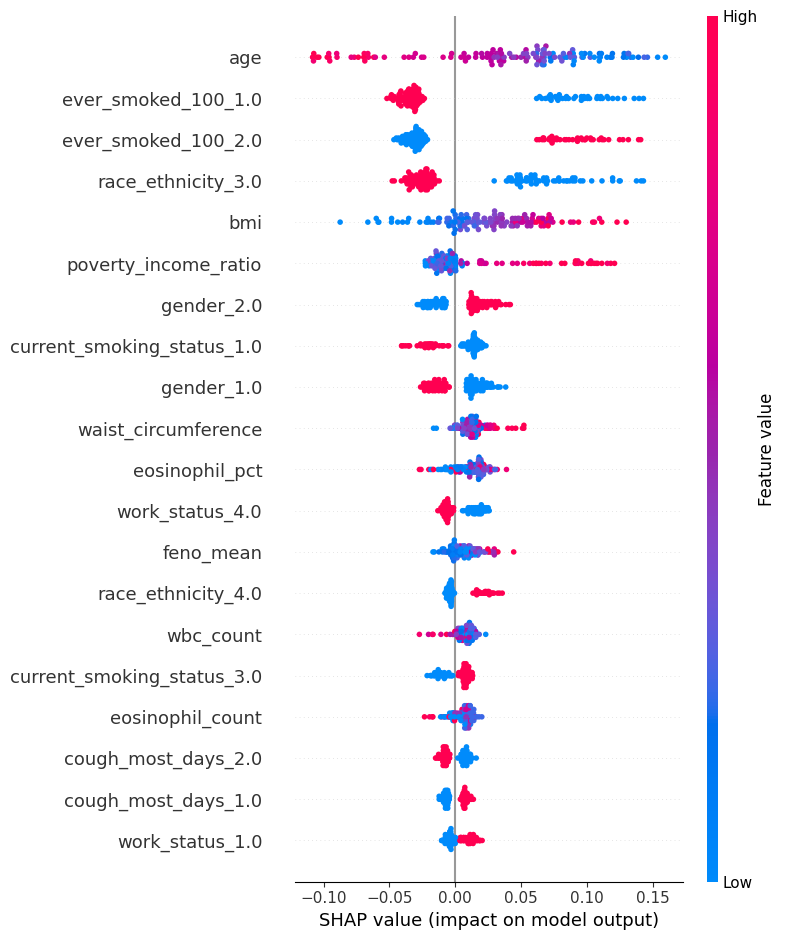


=== FeNO rank comparison ===
         feature  with_imputed  complete_only  rank_imputed  rank_complete
eosinophil_count        0.0048         0.0082          21.0           17.0
  eosinophil_pct        0.0121         0.0144          15.0           11.0
       feno_mean        0.0233         0.0102           6.0           13.0


In [45]:
# Restrict to participants with observed FeNO, then re-run SHAP on Arm C.
# If FeNO holds its rank, the finding is real. If it collapses, it was
# partly an imputation pattern.

feno_obs = X["feno_mean"].notna()
print(f"Complete FeNO: {feno_obs.sum()} of {len(X)} "
      f"({feno_obs.sum()/len(X)*100:.1f}%)")
print("By group:", y[feno_obs].value_counts().to_dict())

X_f, y_f = X[feno_obs], y[feno_obs]
X_fc, num_fc, cat_fc = make_arm(X_f, SPX_FEATURES)

imp_feno, _, _ = run_shap_analysis(X_fc, y_f, num_fc, cat_fc,
                                   model_name="Random Forest")

# Side-by-side with the imputed-data ranking
cmp = (imp_nospx.rename(columns={"mean_abs_shap": "with_imputed"})
       .merge(imp_feno.rename(columns={"mean_abs_shap": "complete_only"}),
              on="feature", how="outer"))
cmp["rank_imputed"] = cmp["with_imputed"].rank(ascending=False)
cmp["rank_complete"] = cmp["complete_only"].rank(ascending=False)
print("\n=== FeNO rank comparison ===")
print(cmp[cmp.feature.str.contains("feno|eosinophil", case=False, na=False)]
      .round(4).to_string(index=False))

In [46]:
# 273 asthma cases (34%) have no spirometry and receive median imputation.
# All 128 COPD cases have spirometry by definition. The imputed value sits
# above the 0.70 threshold, so missingness itself signals "asthma".
# This arm removes that channel.

spx_obs = X[["fev1", "fvc"]].notna().all(axis=1)
print(f"Complete spirometry: {spx_obs.sum()} of {len(X)}")
print("By group:", y[spx_obs].value_counts().to_dict())

X_s, y_s = X[spx_obs], y[spx_obs]
X_sa, num_sa, cat_sa = make_arm(X_s, [])

folds_complete = run_nested_repeated_cv(X_sa, y_s, num_sa, cat_sa,
                                        n_splits=5, n_repeats=10, n_iter=20)
folds_complete.to_csv("nested_cv_folds_A_complete_spx.csv", index=False)
summary_complete = summarise_folds(folds_complete)
print(summary_complete.round(4).to_string(index=False))

print("\n=== Arm A: all cases vs complete-spirometry only ===")
comp = pd.DataFrame({
    "A_all_cases": arm_summary["A_full"].set_index("Model")["AUROC_mean"],
    "A_complete_spx": summary_complete.set_index("Model")["AUROC_mean"],
})
comp["imputation_effect"] = comp["A_all_cases"] - comp["A_complete_spx"]
print(comp.round(4).to_string())
comp.to_csv("imputation_sensitivity.csv")

Complete spirometry: 649 of 922
By group: {1: 521, 0: 128}
    fold 5/50
    fold 10/50
    fold 15/50
    fold 20/50
    fold 25/50
    fold 30/50
    fold 35/50
    fold 40/50
    fold 45/50
    fold 50/50
                Model  N_folds  AUROC_mean  AUROC_sd  AUROC_lo  AUROC_hi  Balanced_Accuracy_mean  Balanced_Accuracy_sd  Balanced_Accuracy_lo  Balanced_Accuracy_hi  Macro_F1_mean  Macro_F1_sd  Macro_F1_lo  Macro_F1_hi  Asthma_Sensitivity_mean  Asthma_Sensitivity_sd  Asthma_Sensitivity_lo  Asthma_Sensitivity_hi  COPD_Sensitivity_mean  COPD_Sensitivity_sd  COPD_Sensitivity_lo  COPD_Sensitivity_hi  Threshold_mean  Threshold_sd  Threshold_lo  Threshold_hi
        Random Forest       50      0.9389    0.0189    0.9038    0.9685                  0.8590                0.0419                0.7751                0.9189         0.7972       0.0387       0.7297       0.8668                   0.8409                 0.0521                 0.7298                 0.9231                 0.8770    

In [47]:
ARMS_D = {"D_no_spx_no_race": SPX_FEATURES + ["race_ethnicity"]}
Xd, num_d, cat_d = make_arm(X, ARMS_D["D_no_spx_no_race"])
folds_d = run_nested_repeated_cv(Xd, y, num_d, cat_d, n_splits=5, n_repeats=10, n_iter=20)
folds_d.to_csv("nested_cv_folds_D_no_race.csv", index=False)
summary_d = summarise_folds(folds_d)
print(summary_d.round(4).to_string(index=False))

print("\n=== Cost of removing race (Arm C vs D) ===")
cmp_d = pd.DataFrame({
    "C_no_spx": arm_summary["C_no_spx"].set_index("Model")["AUROC_mean"],
    "D_no_race": summary_d.set_index("Model")["AUROC_mean"],
})
cmp_d["race_effect"] = cmp_d["C_no_spx"] - cmp_d["D_no_race"]
print(cmp_d.round(4).to_string())

    fold 5/50
    fold 10/50
    fold 15/50
    fold 20/50
    fold 25/50
    fold 30/50
    fold 35/50
    fold 40/50
    fold 45/50
    fold 50/50
                Model  N_folds  AUROC_mean  AUROC_sd  AUROC_lo  AUROC_hi  Balanced_Accuracy_mean  Balanced_Accuracy_sd  Balanced_Accuracy_lo  Balanced_Accuracy_hi  Macro_F1_mean  Macro_F1_sd  Macro_F1_lo  Macro_F1_hi  Asthma_Sensitivity_mean  Asthma_Sensitivity_sd  Asthma_Sensitivity_lo  Asthma_Sensitivity_hi  COPD_Sensitivity_mean  COPD_Sensitivity_sd  COPD_Sensitivity_lo  COPD_Sensitivity_hi  Threshold_mean  Threshold_sd  Threshold_lo  Threshold_hi
XGBoost (regularized)       50      0.8059    0.0382    0.7293    0.8707                  0.7317                0.0389                0.6715                0.8044         0.6399       0.0522       0.5215       0.7170                   0.7550                 0.0938                 0.5311                 0.8959                 0.7083               0.1102               0.4788               0.8724


=== SHAP global importance (Random Forest, top 15) ===
                   feature  mean_abs_shap
       ever_smoked_100_2.0       0.065167
       ever_smoked_100_1.0       0.061281
                       age       0.047061
                       bmi       0.034815
                 feno_mean       0.020672
                gender_2.0       0.017845
       cough_most_days_1.0       0.016957
      poverty_income_ratio       0.016455
                gender_1.0       0.015575
       cough_most_days_2.0       0.013254
       waist_circumference       0.010743
       wheeze_exercise_0.0       0.010738
current_smoking_status_1.0       0.010662
       wheeze_exercise_1.0       0.009089
current_smoking_status_3.0       0.008969


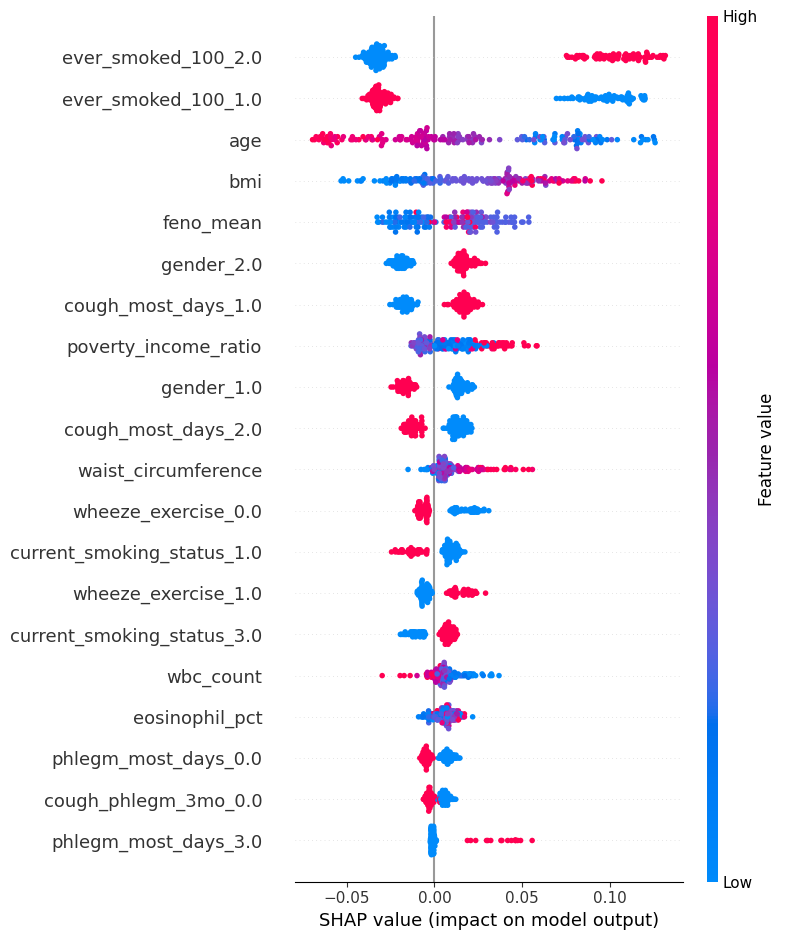

              variable  mean_abs_shap
       ever_smoked_100       0.126448
                   age       0.047061
                   bmi       0.034815
                gender       0.033420
       cough_most_days       0.030211
             feno_mean       0.020672
current_smoking_status       0.020349
       wheeze_exercise       0.019852
  poverty_income_ratio       0.016455
      phlegm_most_days       0.014316
             education       0.011096
   waist_circumference       0.010743
             wbc_count       0.007932
        eosinophil_pct       0.007330
 wheeze_disturbs_sleep       0.006294


In [48]:
X_d, num_d, cat_d = make_arm(X, SPX_FEATURES + ["race_ethnicity"])
imp_final, sv_final, names_final = run_shap_analysis(
    X_d, y, num_d, cat_d, model_name="Random Forest")

# Sum one-hot dummies back to original variables for the publication figure
import re
base = imp_final.copy()
base["variable"] = base["feature"].str.replace(r"_-?\d+\.\d+$", "", regex=True)
grouped = (base.groupby("variable")["mean_abs_shap"].sum()
           .sort_values(ascending=False).reset_index())
print(grouped.head(15).to_string(index=False))

=== Summed mean |SHAP| by original variable ===
                      label  mean_abs_shap
Ever smoked 100+ cigarettes         0.1264
                        Age         0.0471
                        BMI         0.0348
                        Sex         0.0334
            Cough most days         0.0302
                       FeNO         0.0207
     Current smoking status         0.0203
         Wheeze on exertion         0.0199
       Poverty-income ratio         0.0165
           Phlegm most days         0.0143
                  Education         0.0111
        Waist circumference         0.0107
                  WBC count         0.0079
            Eosinophils (%)         0.0073
    Wheeze disturbing sleep         0.0063


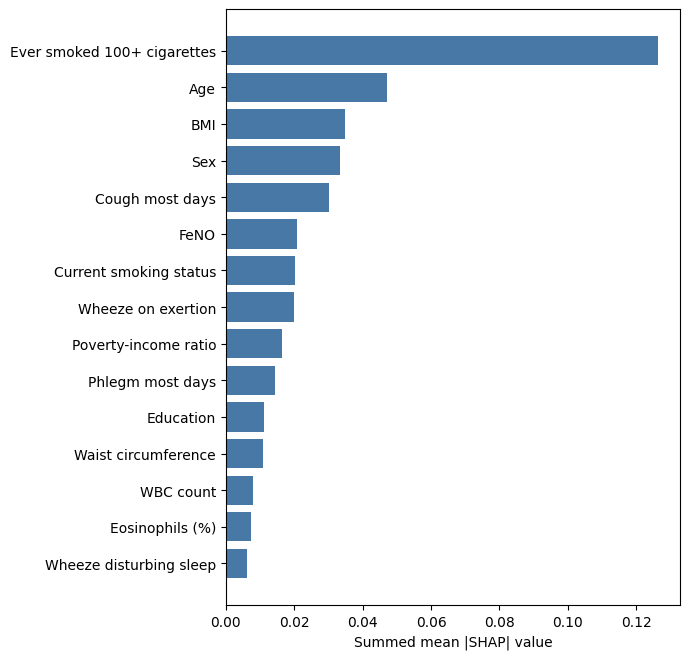


Beeswarm: 30 of 49 columns retained (19 mirrored dummies removed)


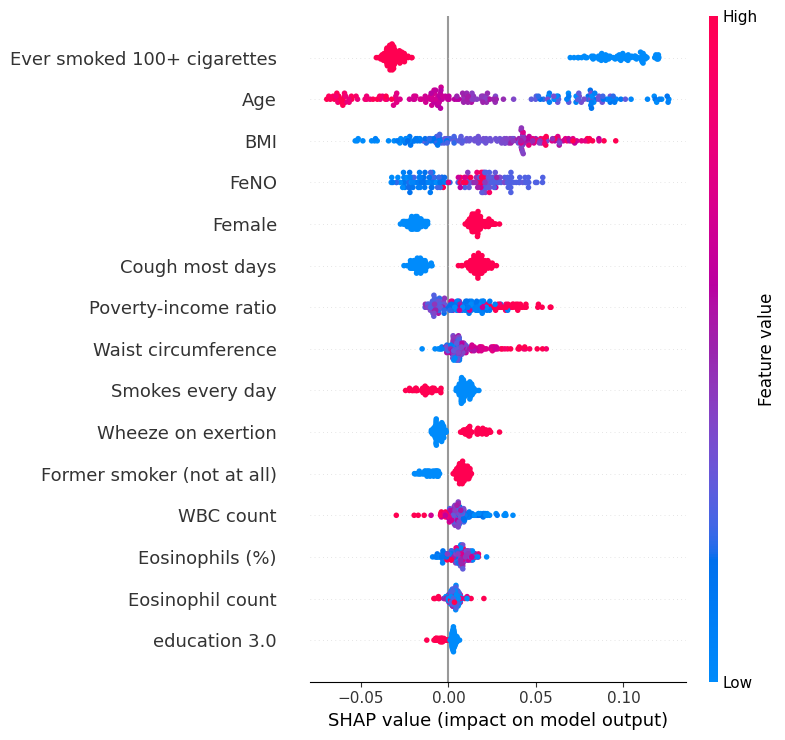

In [ ]:


# ---------------------------------------------------------------------------
# Display labels. VERIFY THESE against the NHANES codebooks before submitting
# — I'm confident about SMQ020, RIAGENDR and SMQ040, less so about the RDQ
# items, where your fillna(0).replace({2:0}) transform interacts with the
# original coding.
# ---------------------------------------------------------------------------
LABELS = {
    "age": "Age",
    "bmi": "BMI",
    "waist_circumference": "Waist circumference",
    "poverty_income_ratio": "Poverty-income ratio",
    "wbc_count": "WBC count",
    "eosinophil_pct": "Eosinophils (%)",
    "eosinophil_count": "Eosinophil count",
    "feno_mean": "FeNO",
    "ever_smoked_100": "Ever smoked 100+ cigarettes",
    "gender": "Sex",
    "current_smoking_status": "Current smoking status",
    "work_status": "Work status",
    "education": "Education",
    "cough_most_days": "Cough most days",
    "phlegm_most_days": "Phlegm most days",
    "cough_phlegm_3mo": "Cough with phlegm 3+ months",
    "wheeze_past_12mo": "Wheeze, past 12 months",
    "wheeze_exercise": "Wheeze on exertion",
    "wheeze_disturbs_sleep": "Wheeze disturbing sleep",
}

# For binary variables, which dummy level to keep and how to name it.
KEEP_LEVEL = {
    "ever_smoked_100": ("1.0", "Ever smoked 100+ cigarettes"),
    "gender":          ("2.0", "Female"),
    "cough_most_days": ("1.0", "Cough most days"),
    "wheeze_past_12mo": ("1.0", "Wheeze, past 12 months"),
    "wheeze_disturbs_sleep": ("1.0", "Wheeze disturbing sleep"),
    "wheeze_exercise": ("1.0", "Wheeze on exertion"),
    "phlegm_most_days": ("1.0", "Phlegm most days"),
    "cough_phlegm_3mo": ("1.0", "Cough with phlegm 3+ months"),
}

# Multi-level categoricals: label each retained level explicitly.
LEVEL_LABELS = {
    "current_smoking_status_1.0": "Smokes every day",
    "current_smoking_status_2.0": "Smokes some days",
    "current_smoking_status_3.0": "Former smoker (not at all)",
    "work_status_1.0": "Working",
    "work_status_2.0": "Employed, not at work",
    "work_status_3.0": "Looking for work",
    "work_status_4.0": "Not working",
}


def split_feature(name):
    """Return (base_variable, level_or_None)."""
    m = re.match(r"^(.*)_(-?\d+\.\d+)$", name)
    return (m.group(1), m.group(2)) if m else (name, None)


def shap_publication_figure(X, y, numeric_cols, categorical_cols,
                            model_name="Random Forest", n_iter=30, top_n=15):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    prep = build_preprocessor(categorical_cols, numeric_cols)
    clf, params = get_model_specs(spw)[model_name]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    search = RandomizedSearchCV(Pipeline([("prep", prep), ("clf", clf)]), params,
        n_iter=n_iter, scoring="roc_auc", cv=cv, random_state=RANDOM_SEED, n_jobs=-1)
    search.fit(X_tr, y_tr)
    pipe = search.best_estimator_

    prep_f, clf_f = pipe.named_steps["prep"], pipe.named_steps["clf"]
    names = get_feature_names(prep_f, numeric_cols, categorical_cols)
    X_enc = prep_f.transform(X_te)
    if hasattr(X_enc, "toarray"):
        X_enc = X_enc.toarray()

    sv = shap.TreeExplainer(clf_f).shap_values(X_enc)
    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]

    mean_abs = np.abs(sv).mean(axis=0)
    meta = pd.DataFrame({"feature": names, "mean_abs_shap": mean_abs})
    meta[["base", "level"]] = meta["feature"].apply(
        lambda s: pd.Series(split_feature(s)))

    # ---- FIX 3: grouped importance (Panel A) ----
    grouped = (meta.groupby("base")["mean_abs_shap"].sum()
               .sort_values(ascending=False).reset_index())
    grouped["label"] = grouped["base"].map(LABELS).fillna(grouped["base"])
    print("=== Summed mean |SHAP| by original variable ===")
    print(grouped[["label", "mean_abs_shap"]].head(top_n)
          .round(4).to_string(index=False))

    g = grouped.head(top_n).iloc[::-1]
    plt.figure(figsize=(7, 0.38 * len(g) + 1))
    plt.barh(g["label"], g["mean_abs_shap"], color="#4878A6")
    plt.xlabel("Summed mean |SHAP| value")
    plt.tight_layout()
    plt.savefig("fig_shap_grouped.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---- FIXES 1 & 2: drop mirrored dummies, relabel (Panel B) ----
    keep_idx, keep_labels = [], []
    for i, row in meta.iterrows():
        base, lvl = row["base"], row["level"]
        if lvl is None:                                  # numeric
            keep_idx.append(i); keep_labels.append(LABELS.get(base, base)); continue
        if base in KEEP_LEVEL:                           # binary -> one dummy
            want, lab = KEEP_LEVEL[base]
            if lvl == want:
                keep_idx.append(i); keep_labels.append(lab)
            continue
        key = f"{base}_{lvl}"                            # multi-level -> keep all
        keep_idx.append(i)
        keep_labels.append(LEVEL_LABELS.get(key, key.replace("_", " ")))

    print(f"\nBeeswarm: {len(keep_idx)} of {len(names)} columns retained "
          f"({len(names) - len(keep_idx)} mirrored dummies removed)")

    shap.summary_plot(sv[:, keep_idx], X_enc[:, keep_idx],
                      feature_names=keep_labels, max_display=top_n, show=False)
    plt.tight_layout()
    plt.savefig("fig_shap_beeswarm.png", dpi=300, bbox_inches="tight")
    plt.show()

    grouped.to_csv("shap_grouped_importance.csv", index=False)
    return grouped, meta, sv, X_enc, keep_idx, keep_labels


# Arm D: spirometry-free and race-free — the final reported model
X_d, num_d, cat_d = make_arm(X, SPX_FEATURES + ["race_ethnicity"])
grouped, meta, sv_d, X_enc_d, keep_idx, keep_labels = shap_publication_figure(
    X_d, y, num_d, cat_d, model_name="Random Forest")

=== Summed mean |SHAP| by original variable ===
                      label  mean_abs_shap
Ever smoked 100+ cigarettes         0.1264
                        Age         0.0471
                        BMI         0.0348
                        Sex         0.0334
            Cough most days         0.0302
                       FeNO         0.0207
     Current smoking status         0.0203
         Wheeze on exertion         0.0199
       Poverty-income ratio         0.0165
           Phlegm most days         0.0143
                  Education         0.0111
        Waist circumference         0.0107
                  WBC count         0.0079
            Eosinophils (%)         0.0073
    Wheeze disturbing sleep         0.0063


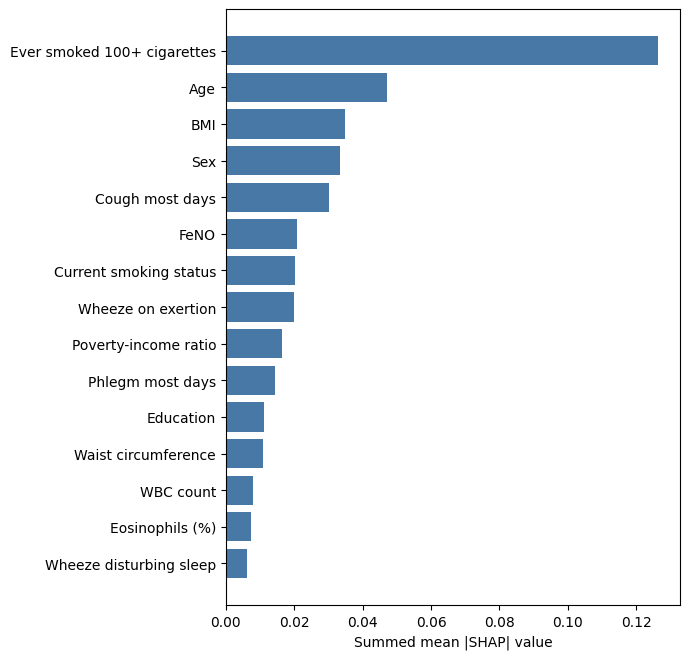


Beeswarm: 30 of 49 columns retained (19 mirrored dummies removed)


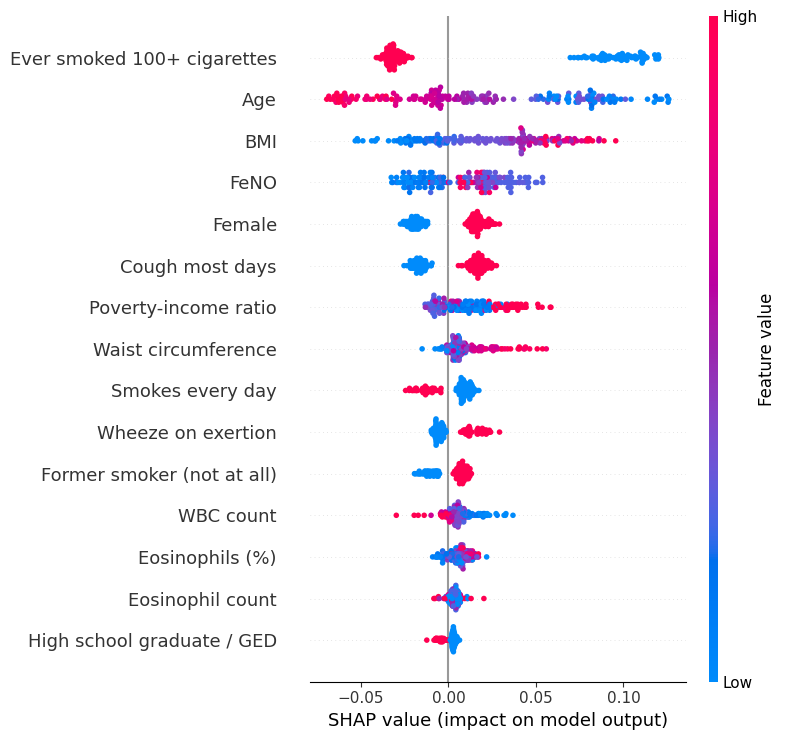

In [50]:
LEVEL_LABELS.update({
    "education_1.0": "Less than 9th grade",
    "education_2.0": "9th-11th grade",
    "education_3.0": "High school graduate / GED",
    "education_4.0": "Some college or AA degree",
    "education_5.0": "College graduate or above",
})

# Re-run — only the beeswarm labels change
X_d, num_d, cat_d = make_arm(X, SPX_FEATURES + ["race_ethnicity"])
grouped, meta, sv_d, X_enc_d, keep_idx, keep_labels = shap_publication_figure(
    X_d, y, num_d, cat_d, model_name="Random Forest")